=== RÉSULTATS ===
Prix Exact (BS)  : 10.4506 €
Prix Numérique   : 10.4302 €
Erreur Absolue   : 0.0204 €


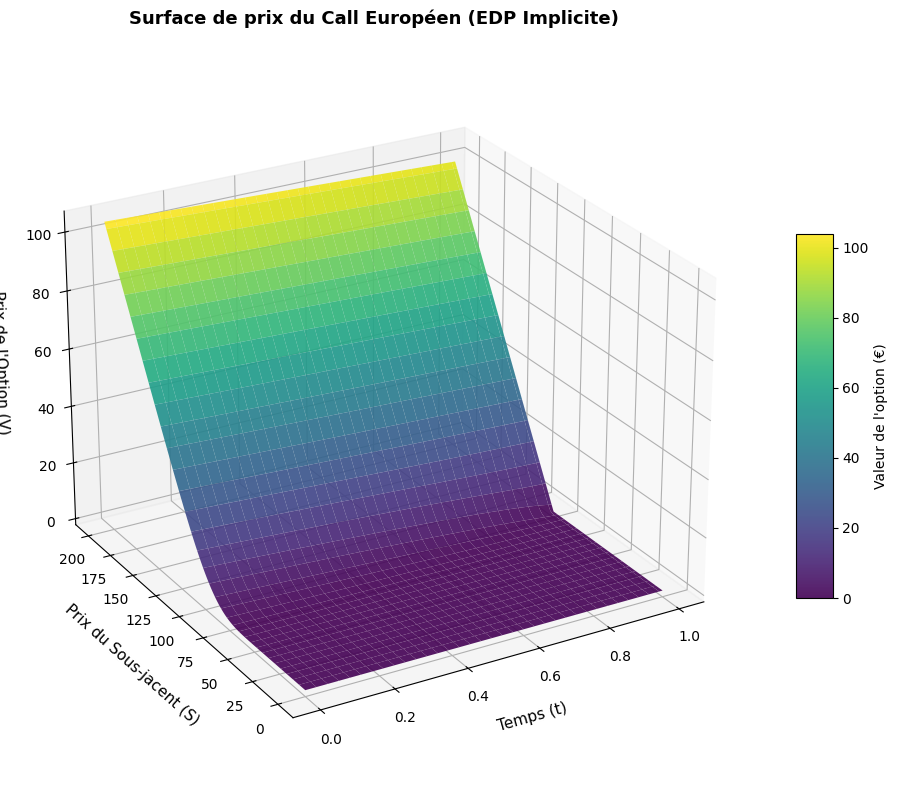

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import splu
from scipy.stats import norm


def prix_call_black_scholes(S, K, tau, r, sigma):
    """Prix analytique d'un call européen sans dividende."""
    S = np.asarray(S, dtype=float)
    if tau <= 0:
        resultat = np.maximum(S - K, 0.0)
    else:
        resultat = np.zeros_like(S)
        masque = S > 0
        d1 = (
            np.log(S[masque] / K)
            + (r + 0.5 * sigma**2) * tau
        ) / (sigma * np.sqrt(tau))
        d2 = d1 - sigma * np.sqrt(tau)
        resultat[masque] = (
            S[masque] * norm.cdf(d1)
            - K * np.exp(-r * tau) * norm.cdf(d2)
        )
    return resultat.item() if resultat.ndim == 0 else resultat


def differences_finies_implicites(S0, K, T, r, sigma, S_max, M, N):
    """Résout l'EDP de Black-Scholes par Euler implicite."""
    if not (0 < S0 < S_max and K > 0 and T > 0 and sigma > 0):
        raise ValueError("Paramètres financiers ou domaine invalides.")
    if M < 3 or N < 1:
        raise ValueError("M doit être >= 3 et N doit être >= 1.")

    dS = S_max / M
    dt = T / N
    S = np.linspace(0.0, S_max, M + 1)
    t = np.linspace(0.0, T, N + 1)
    V = np.zeros((M + 1, N + 1))

    # Condition terminale et conditions aux limites du call.
    V[:, -1] = np.maximum(S - K, 0.0)
    V[0, :] = 0.0
    V[-1, :] = S_max - K * np.exp(-r * (T - t))

    # Matrice tridiagonale du schéma implicite.
    i = np.arange(1, M, dtype=float)
    a = 0.5 * dt * (r * i - sigma**2 * i**2)
    b = 1.0 + dt * (sigma**2 * i**2 + r)
    c = -0.5 * dt * (r * i + sigma**2 * i**2)
    A = diags(
        diagonals=(a[1:], b, c[:-1]),
        offsets=(-1, 0, 1),
        shape=(M - 1, M - 1),
        format="csc",
    )

    # Une seule factorisation LU est réutilisée à tous les pas de temps.
    lu = splu(A)
    for n in range(N - 1, -1, -1):
        second_membre = V[1:M, n + 1].copy()
        second_membre[0] -= a[0] * V[0, n]
        second_membre[-1] -= c[-1] * V[-1, n]
        V[1:M, n] = lu.solve(second_membre)

    prix_initial = np.interp(S0, S, V[:, 0])
    return S, t, V, prix_initial


def etude_convergence(S0, K, T, r, sigma, S_max, maillages):
    """Compare plusieurs maillages à la formule analytique."""
    prix_exact = prix_call_black_scholes(S0, K, T, r, sigma)
    lignes = []
    erreur_precedente = None
    taille_precedente = None

    for M, N in maillages:
        _, _, _, prix = differences_finies_implicites(
            S0, K, T, r, sigma, S_max, M, N
        )
        erreur = abs(prix - prix_exact)
        ordre = np.nan
        if erreur_precedente is not None and erreur > 0:
            ordre = np.log(erreur_precedente / erreur) / np.log(
                M / taille_precedente
            )
        lignes.append((M, N, prix, erreur, ordre))
        erreur_precedente = erreur
        taille_precedente = M

    return prix_exact, lignes


if __name__ == "__main__":
    S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20
    S_max = 4.0 * K

    # Étude de convergence.
    prix_exact, tableau = etude_convergence(
        S0,
        K,
        T,
        r,
        sigma,
        S_max,
        maillages=((50, 100), (100, 400), (200, 1600), (400, 6400)),
    )
    print(" M     N        prix          erreur       ordre observe")
    for M, N, prix, erreur, ordre in tableau:
        ordre_texte = "-" if np.isnan(ordre) else f"{ordre:.3f}"
        print(
            f"{M:4d}  {N:4d}   {prix:11.7f}   "
            f"{erreur:10.3e}      {ordre_texte}"
        )
    print(f"\nPrix analytique : {prix_exact:.7f}")

    # Grille fine utilisée pour les figures.
    S, t, V, prix_df = differences_finies_implicites(
        S0, K, T, r, sigma, S_max, M=400, N=6400
    )
    print(f"Prix différences finies : {prix_df:.7f}")

    # Surface limitée à S <= 2K pour conserver une échelle lisible.
    masque = S <= 2.0 * K
    pas_s = 4
    pas_t = max(1, (len(t) - 1) // 200)
    T_plot, S_plot = np.meshgrid(
        t[::pas_t], S[masque][::pas_s]
    )
    V_plot = V[masque, :][::pas_s, ::pas_t]

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")
    surface = ax.plot_surface(
        T_plot, S_plot, V_plot, cmap="viridis", edgecolor="none"
    )
    ax.set_xlabel("Temps t")
    ax.set_ylabel("Sous-jacent S")
    ax.set_zlabel("Prix du call")
    ax.set_title("Schéma implicite pour l'EDP de Black-Scholes")
    fig.colorbar(surface, ax=ax, shrink=0.6, label="Prix")
    fig.tight_layout()
    fig.savefig("surface_edp.pdf", bbox_inches="tight")

    # Profils du prix à plusieurs dates.
    plt.figure(figsize=(9, 6))
    for date in (0.0, 0.25, 0.50, 0.75, 1.0):
        n = int(np.argmin(np.abs(t - date)))
        plt.plot(S[masque], V[masque, n], label=f"t = {t[n]:.2f}")
    plt.xlabel("Sous-jacent S")
    plt.ylabel("Prix du call")
    plt.title("Prix du call pour plusieurs dates")
    plt.grid(linestyle=":", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        "graphe_2D_call_plusieurs_t.png",
        dpi=300,
        bbox_inches="tight",
    )

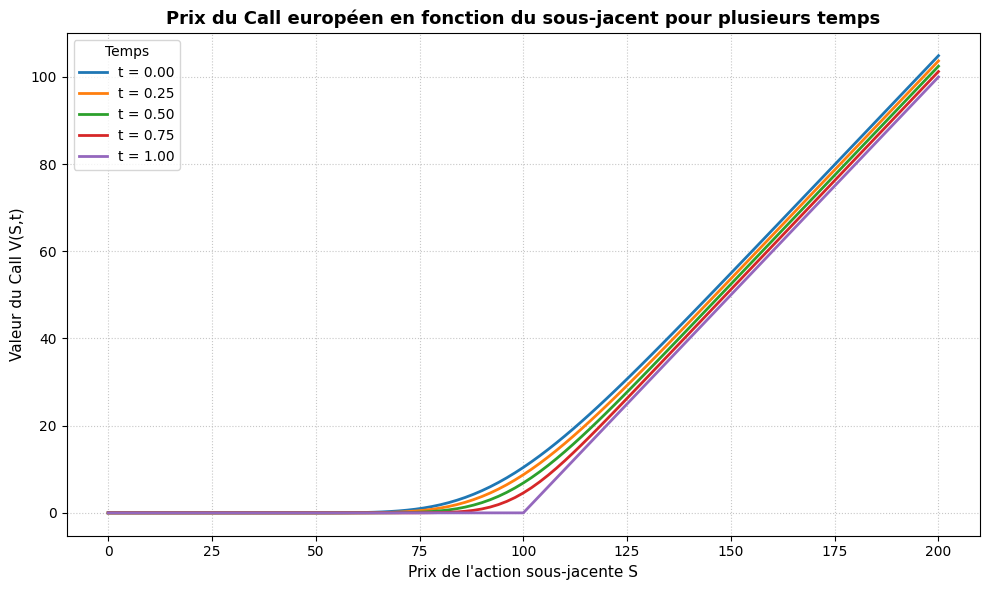

In [ ]:
#=================================================================
# 4. GRAPHE 2D DU PRIX DE L'OPTION POUR PLUSIEURS TEMPS
#=================================================================

# Temps choisis entre la date initiale t = 0 et la maturité T = 1
temps_choisis = [0.0, 0.25, 0.50, 0.75, 1.0]

plt.figure(figsize=(10, 6))

# Une courbe est tracée pour chaque valeur de t
for t_fix in temps_choisis:
    # Recherche de l'indice de temps le plus proche de t_fix
    indice_t = np.argmin(np.abs(t_grid - t_fix))

    # Temps réellement pris dans la grille
    t_reel = t_grid[indice_t]

    # Prix du Call en fonction du sous-jacent à l'instant t
    plt.plot(
        S_grid,
        V_matrice[:, indice_t],
        linewidth=2,
        label=f"t = {t_reel:.2f}",
    )

plt.title(
    "Prix du Call européen en fonction du sous-jacent pour plusieurs temps",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Prix de l'action sous-jacente S", fontsize=11)
plt.ylabel("Valeur du Call V(S,t)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(title="Temps")
plt.tight_layout()

# Sauvegarde du graphe
plt.savefig(
    "graphe_2D_call_plusieurs_t.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
